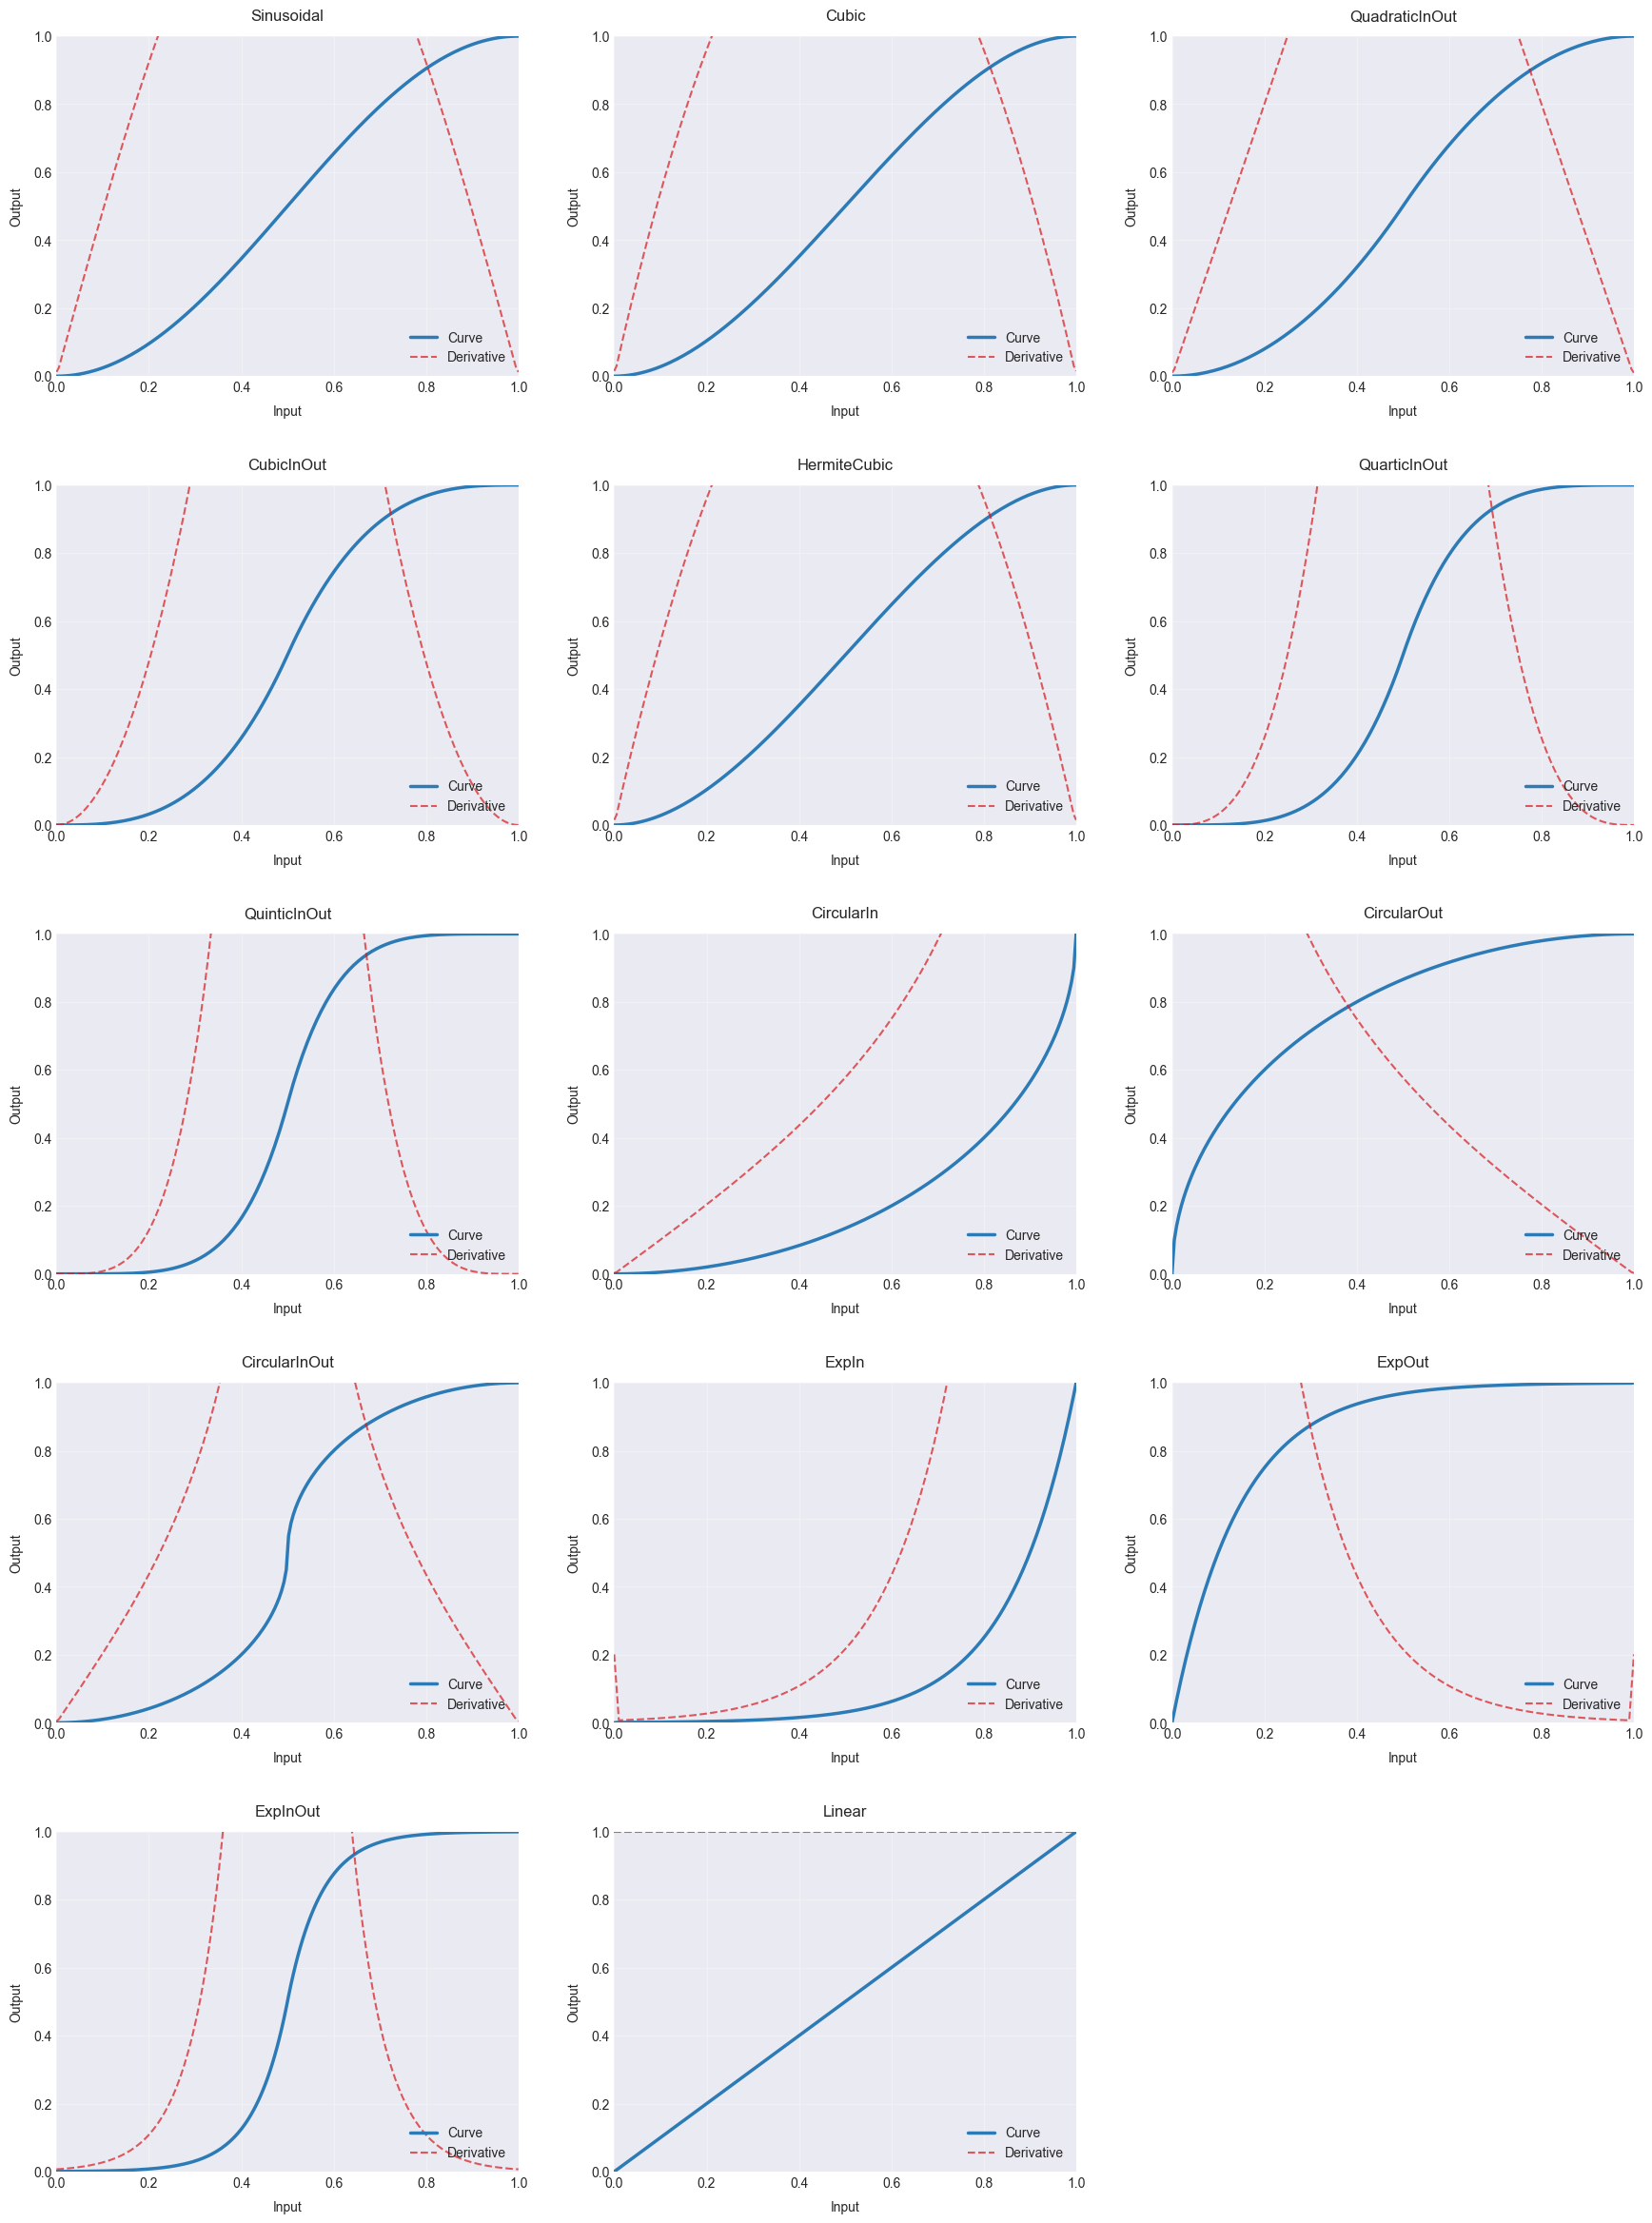

In [18]:
# alpha_blend_curves.ipynb

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# 配置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']  # 添加备用字体
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-darkgrid')

# 确保字体文件存在
import matplotlib.font_manager as fm
font_path = fm.findfont('SimHei')
if not font_path:
    print("警告：SimHei字体未找到，将使用系统默认字体")
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'WenQuanYi Micro Hei']
# 基础数学参数
PI = np.pi
HALF_PI = PI / 2

# 辅助函数 ------------------------------------------------------------
def clamp(x, min_val=0.0, max_val=1.0):
    return np.clip(x, min_val, max_val)

# 实现所有插值算法 -----------------------------------------------------

# 1. 正弦曲线
def sinusoidal(alpha):
    return clamp((np.sin(alpha * PI - HALF_PI) + 1) / 2)

# 2. 三次插值
def cubic(alpha):
    return clamp(-2*alpha**3 + 3*alpha**2)

# 3. 二次缓入缓出
def quadratic_in_out(alpha):
    alpha = clamp(alpha)
    return np.where(
        alpha < 0.5,
        0.5 * (2*alpha)**2,
        1 - 0.5 * (2*(1 - alpha))**2
    )

# 4. 三次缓入缓出
def cubic_in_out(alpha):
    alpha = clamp(alpha)
    return np.where(
        alpha < 0.5,
        4 * alpha**3,
        1 - 4 * (1 - alpha)**3
    )

# 5. Hermite三次
def hermite_cubic(alpha):
    return clamp(3*alpha**2 - 2*alpha**3)

# 6. 四次缓入缓出
def quartic_in_out(alpha):
    alpha = clamp(alpha)
    return np.where(
        alpha < 0.5,
        8 * alpha**4,
        1 - 8 * (1 - alpha)**4
    )

# 7. 五次缓入缓出
def quintic_in_out(alpha):
    alpha = clamp(alpha)
    return np.where(
        alpha < 0.5,
        16 * alpha**5,
        1 - 16 * (1 - alpha)**5
    )

# 8. 圆形缓入
def circular_in(alpha):
    return clamp(1 - np.sqrt(1 - alpha**2))

# 9. 圆形缓出
def circular_out(alpha):
    return clamp(np.sqrt(1 - (alpha - 1)**2))

# 10. 圆形缓入缓出
def circular_in_out(alpha):
    alpha = clamp(alpha)
    return np.where(
        alpha < 0.5,
        0.5 * (1 - np.sqrt(np.maximum(1 - (2*alpha)**2,0))),
        0.5 * (np.sqrt(np.maximum(1 - (2*(alpha - 1.0))**2, 0)) + 1)
    )

# 11. 指数缓入
def exp_in(alpha):
    return np.where(alpha <= 0, 0, clamp(2**(10*(alpha-1))))

# 12. 指数缓出
def exp_out(alpha):
    return np.where(alpha >= 1, 1, clamp(1 - 2**(-10*alpha)))

# 13. 指数缓入缓出
def exp_in_out(alpha):
    alpha = clamp(alpha)
    return np.where(
        alpha < 0.5,
        0.5 * 2**(10*(2*alpha - 1)),
        0.5 * (2 - 2**(-10*(2*alpha - 1)))
    )

# 14. 线性（基准）
def linear(alpha):
    return clamp(alpha)

# 生成测试数据 --------------------------------------------------------
x = np.linspace(0, 1, 200)
functions = [
    ("Sinusoidal", sinusoidal),
    ("Cubic", cubic),
    ("QuadraticInOut", quadratic_in_out),
    ("CubicInOut", cubic_in_out),
    ("HermiteCubic", hermite_cubic),
    ("QuarticInOut", quartic_in_out),
    ("QuinticInOut", quintic_in_out),
    ("CircularIn", circular_in),
    ("CircularOut", circular_out),
    ("CircularInOut", circular_in_out),
    ("ExpIn", exp_in),
    ("ExpOut", exp_out),
    ("ExpInOut", exp_in_out),
    ("Linear", linear)
]

# 绘制所有曲线 --------------------------------------------------------
fig = plt.figure(figsize=(18, 24))
gs = GridSpec(5, 3, figure=fig)

for idx, (name, func) in enumerate(functions):
    ax = fig.add_subplot(gs[idx//3, idx%3])
    y = func(x)
    ax.plot(x, y, lw=2.5, color='#2c7bb6')
    ax.set_title(f"{name}", pad=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r"Input", labelpad=8)
    ax.set_ylabel(r"Output", labelpad=8)

    # 添加导数曲线
    dy = np.gradient(y, x)
    ax.plot(x, dy, lw=1.5, linestyle='--', color='#d7191c', alpha=0.7)
    ax.legend([r'Curve', r'Derivative'], loc='lower right')

plt.tight_layout(pad=3.0)
plt.show()


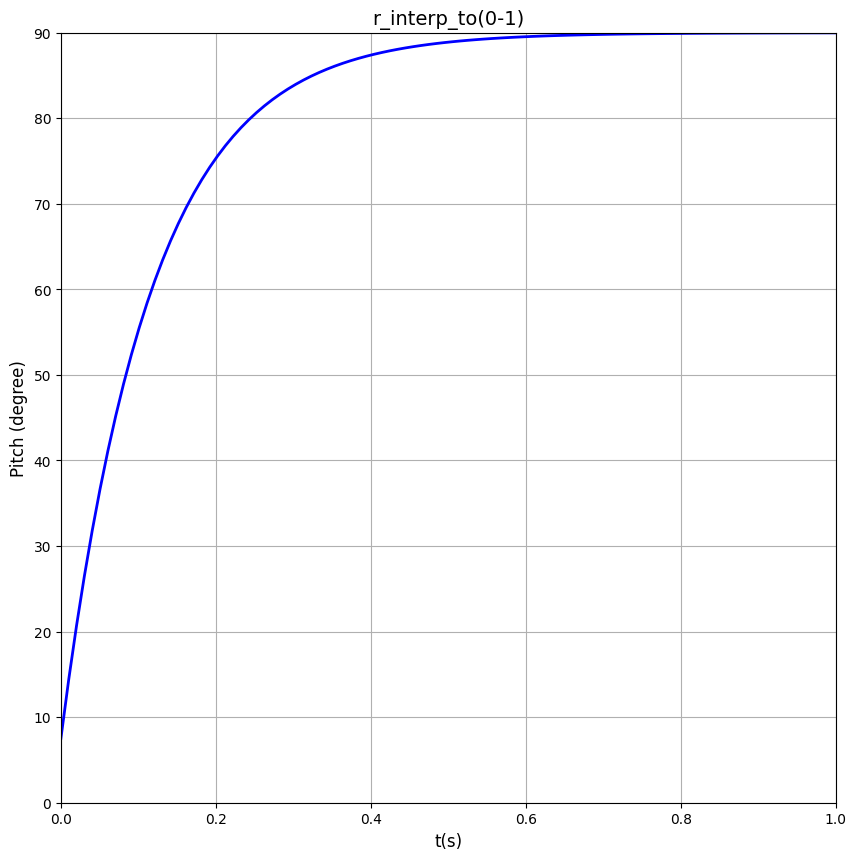

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from math import isclose

class FRotator:
    def __init__(self, pitch=0.0, yaw=0.0, roll=0.0):
        self.pitch = pitch
        self.yaw = yaw
        self.roll = roll

    def __sub__(self, other):
        return FRotator(
            self.pitch - other.pitch,
            self.yaw - other.yaw,
            self.roll - other.roll
        )

    def __add__(self, other):
        return FRotator(
            self.pitch + other.pitch,
            self.yaw + other.yaw,
            self.roll + other.roll
        )

    def __mul__(self, scalar):
        return FRotator(
            self.pitch * scalar,
            self.yaw * scalar,
            self.roll * scalar
        )

    def __eq__(self, other):
        return (isclose(self.pitch, other.pitch) and
                isclose(self.yaw, other.yaw) and
                isclose(self.roll, other.roll))

    def get_normalized(self):
        # 简化版的归一化，实际项目中需要更复杂的角度归一化
        return FRotator(
            self.pitch % 360,
            self.yaw % 360,
            self.roll % 360
        )

    def is_nearly_zero(self, tolerance=1e-4):
        return (abs(self.pitch) < tolerance and
                abs(self.yaw) < tolerance and
                abs(self.roll) < tolerance)

def r_interp_to(current, target, delta_time, interp_speed):
    """
    在两个旋转角度之间进行平滑插值
    :param current: 当前旋转角度
    :param target: 目标旋转角度
    :param delta_time: 时间增量
    :param interp_speed: 插值速度
    :return: 插值后的旋转角度
    """
    # 如果时间增量为0或已经到达目标，直接返回当前值
    if delta_time == 0.0 or current == target:
        return current

    # 如果插值速度为0或负数，直接跳转到目标值
    if interp_speed <= 0.0:
        return target

    delta_interp_speed = interp_speed * delta_time

    # 计算角度差并归一化
    delta = (target - current).get_normalized()

    # 如果角度差非常小，认为已经到达目标
    if delta.is_nearly_zero():
        return target

    # 计算插值增量，并限制在0-1范围内
    delta_move = delta * np.clip(delta_interp_speed, 0.0, 1.0)
    return (current + delta_move).get_normalized()

# 准备绘图数据
time_steps = np.linspace(0, 1, 100)  # 0到1的时间范围
current = FRotator(0, 0, 0)  # 初始角度
target = FRotator(90, 0, 0)  # 目标角度
interp_speed = 5.0  # 插值速度

# 计算插值结果
results = []
for t in time_steps:
    # 假设每步时间增量为0.02秒
    result = r_interp_to(current, target, 0.0167, interp_speed)
    results.append(result.pitch)  # 只绘制pitch的变化
    current = result  # 更新当前值为插值结果

# 绘制曲线
plt.figure(figsize=(10, 10))
plt.plot(time_steps, results, 'b-', linewidth=2)
plt.title(r'r_interp_to(0-1)', fontsize=14)
plt.xlabel(r't(s)', fontsize=12)
plt.ylabel(r'Pitch (degree)', fontsize=12)
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, 90)  # 因为我们从0度插值到90度
plt.show()


C:\Users\zhongkailiu\AppData\Local\Temp\ipykernel_61280\2546640823.py:126: UserWarning: Glyph 35282 (\N{CJK UNIFIED IDEOGRAPH-89D2}) missing from current font.
  plt.tight_layout()
C:\Users\zhongkailiu\AppData\Local\Temp\ipykernel_61280\2546640823.py:126: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.tight_layout()
C:\Users\zhongkailiu\AppData\Local\Temp\ipykernel_61280\2546640823.py:126: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from current font.
  plt.tight_layout()
C:\Users\zhongkailiu\AppData\Local\Temp\ipykernel_61280\2546640823.py:126: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from current font.
  plt.tight_layout()
C:\Users\zhongkailiu\AppData\Local\Temp\ipykernel_61280\2546640823.py:126: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from current font.
  plt.tight_layout()
C:\Users\zhongkailiu\AppData\Local\Temp\ipykernel_61280\2546640823.py:126: UserWarning: Glyph 3

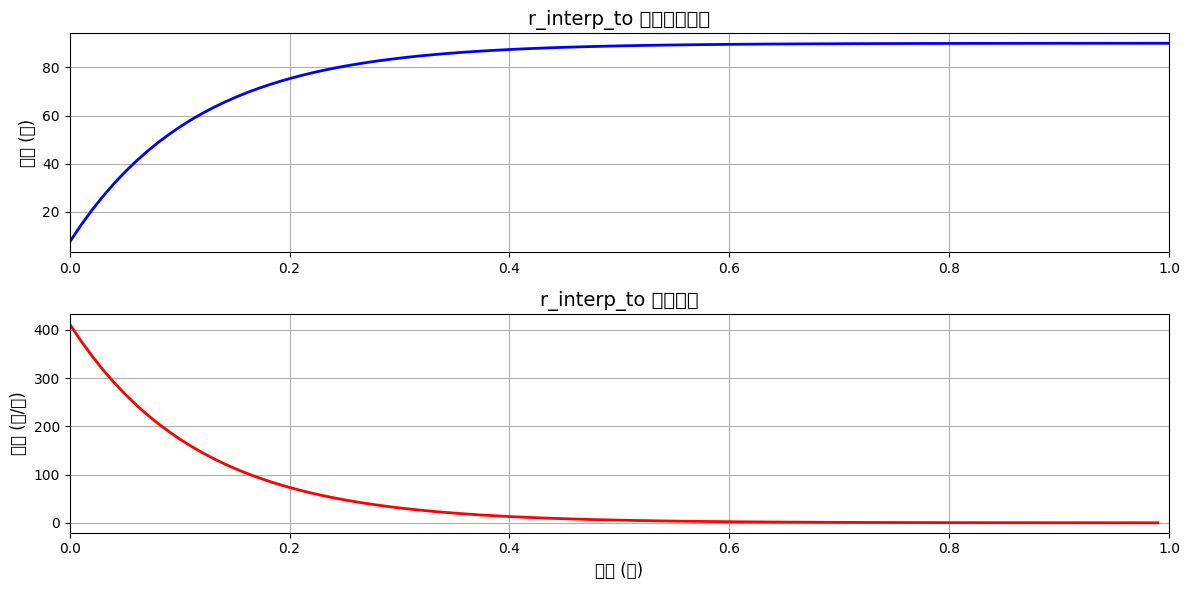

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from math import isclose

class FRotator:
    def __init__(self, pitch=0.0, yaw=0.0, roll=0.0):
        self.pitch = pitch
        self.yaw = yaw
        self.roll = roll

    def __sub__(self, other):
        return FRotator(
            self.pitch - other.pitch,
            self.yaw - other.yaw,
            self.roll - other.roll
        )

    def __add__(self, other):
        return FRotator(
            self.pitch + other.pitch,
            self.yaw + other.yaw,
            self.roll + other.roll
        )

    def __mul__(self, scalar):
        return FRotator(
            self.pitch * scalar,
            self.yaw * scalar,
            self.roll * scalar
        )

    def __eq__(self, other):
        return (isclose(self.pitch, other.pitch) and
                isclose(self.yaw, other.yaw) and
                isclose(self.roll, other.roll))

    def get_normalized(self):
        # 简化版的归一化，实际项目中需要更复杂的角度归一化
        return FRotator(
            self.pitch % 360,
            self.yaw % 360,
            self.roll % 360
        )

    def is_nearly_zero(self, tolerance=1e-4):
        return (abs(self.pitch) < tolerance and
                abs(self.yaw) < tolerance and
                abs(self.roll) < tolerance)

def r_interp_to(current, target, delta_time, interp_speed):
    """
    在两个旋转角度之间进行平滑插值
    :param current: 当前旋转角度
    :param target: 目标旋转角度
    :param delta_time: 时间增量
    :param interp_speed: 插值速度
    :return: 插值后的旋转角度
    """
    # 如果时间增量为0或已经到达目标，直接返回当前值
    if delta_time == 0.0 or current == target:
        return current

    # 如果插值速度为0或负数，直接跳转到目标值
    if interp_speed <= 0.0:
        return target

    delta_interp_speed = interp_speed * delta_time

    # 计算角度差并归一化
    delta = (target - current).get_normalized()

    # 如果角度差非常小，认为已经到达目标
    if delta.is_nearly_zero():
        return target

    # 计算插值增量，并限制在0-1范围内
    delta_move = delta * np.clip(delta_interp_speed, 0.0, 1.0)
    return (current + delta_move).get_normalized()

# 准备绘图数据
time_steps = np.linspace(0, 1, 100)  # 0到1秒的时间范围
delta_time = 0.0167  # 每帧时间(约60FPS)
current = FRotator(0, 0, 0)  # 初始角度
target = FRotator(90, 0, 0)  # 目标角度
interp_speed = 5.0  # 插值速度

# 计算插值结果和速度
positions = []  # 存储角度位置
velocities = []  # 存储角度速度(度/秒)
prev_pos = 0

for t in time_steps:
    result = r_interp_to(current, target, delta_time, interp_speed)
    positions.append(result.pitch)

    # 计算瞬时速度 (度/秒)
    if len(positions) > 1:
        velocity = (result.pitch - prev_pos) / delta_time
        velocities.append(velocity)
    prev_pos = result.pitch
    current = result

# 因为速度计算需要前后两点，所以时间点少一个
velocity_time_steps = time_steps[:-1]

# 创建图形
plt.figure(figsize=(12, 6))

# 绘制位置曲线
plt.subplot(2, 1, 1)
plt.plot(time_steps, positions, 'b-', linewidth=2)
plt.title('r_interp_to 角度位置曲线', fontsize=14)
plt.ylabel('角度 (度)', fontsize=12)
plt.grid(True)
plt.xlim(0, 1)

# 绘制速度曲线
plt.subplot(2, 1, 2)
plt.plot(velocity_time_steps, velocities, 'r-', linewidth=2)
plt.title('r_interp_to 速度曲线', fontsize=14)
plt.xlabel('时间 (秒)', fontsize=12)
plt.ylabel('速度 (度/秒)', fontsize=12)
plt.grid(True)
plt.xlim(0, 1)

plt.tight_layout()
plt.show()


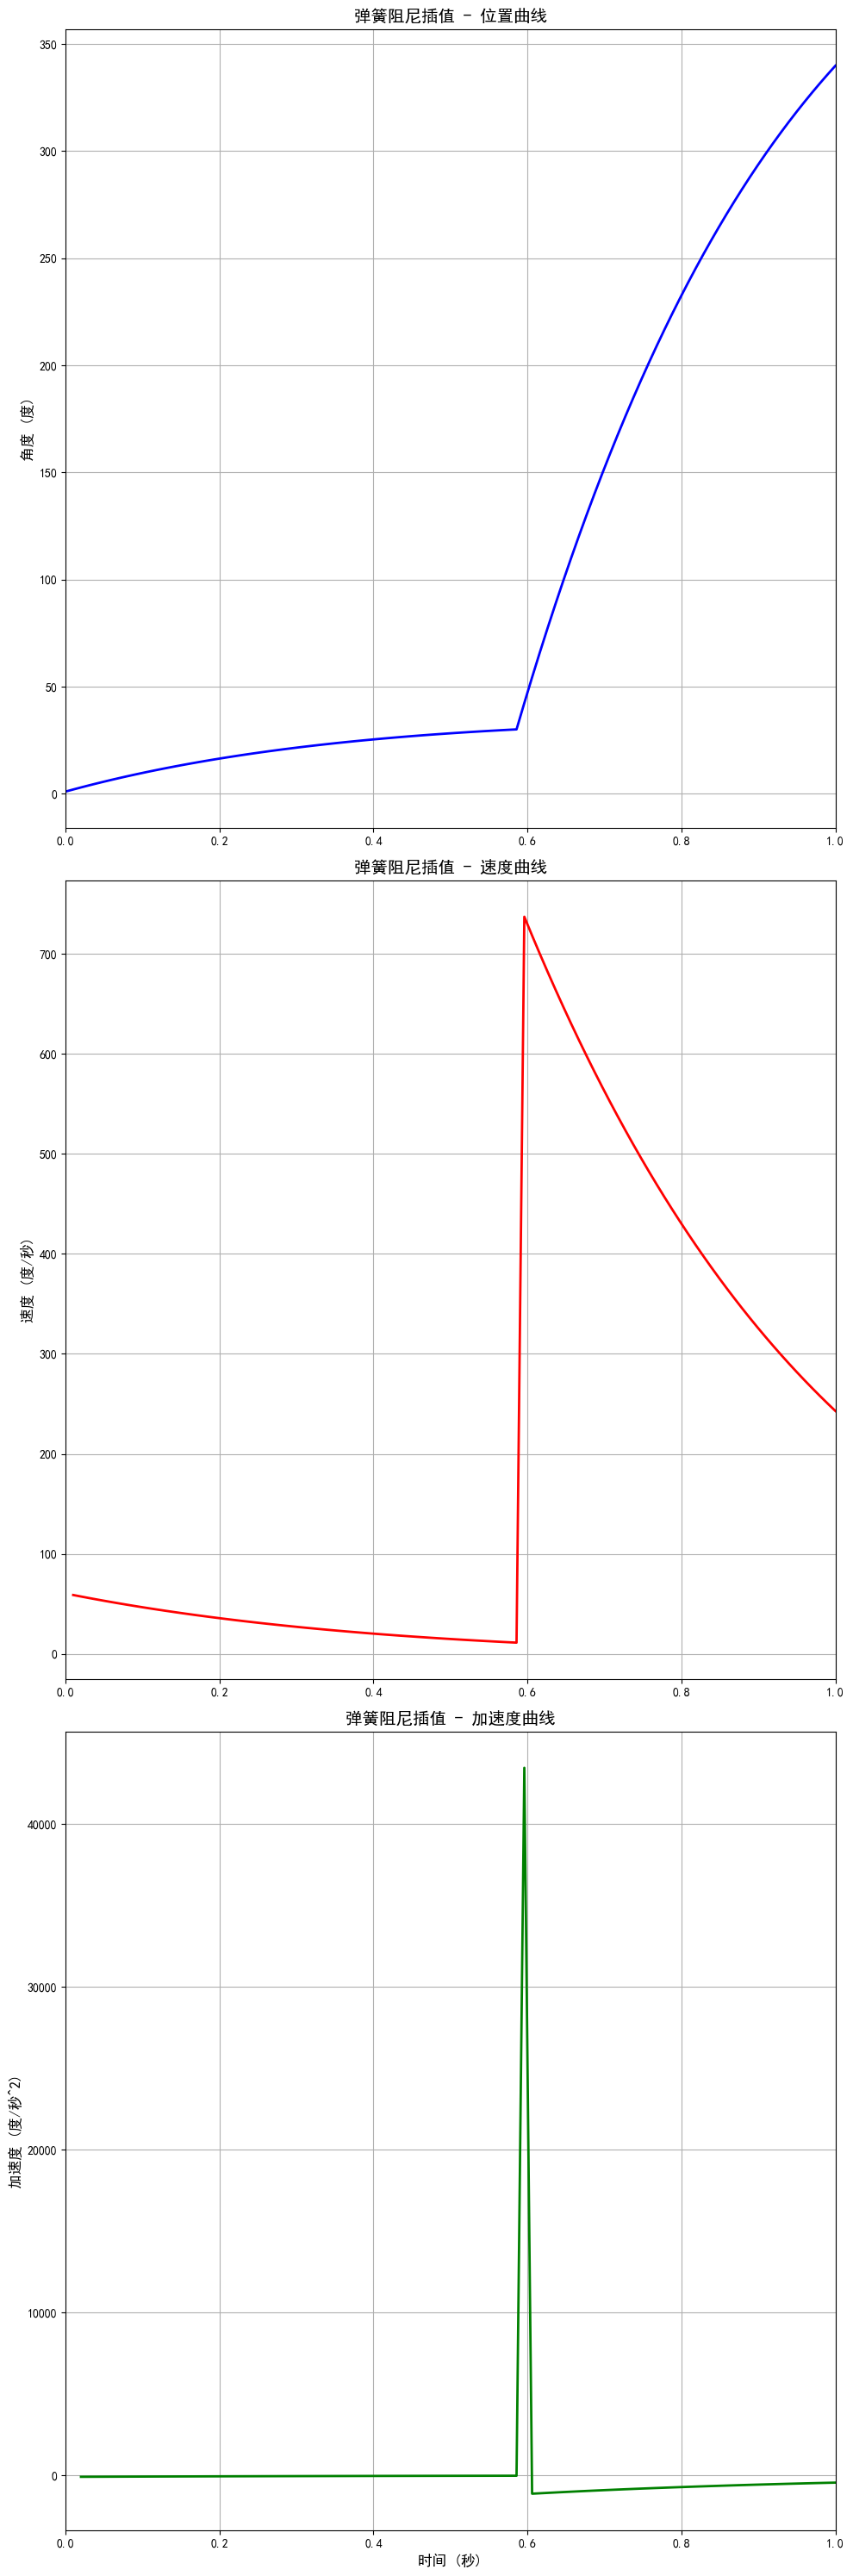

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from math import isclose, sqrt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

class FRotator:
    def __init__(self, pitch=0.0, yaw=0.0, roll=0.0):
        self.pitch = pitch
        self.yaw = yaw
        self.roll = roll

    def __sub__(self, other):
        return FRotator(
            self.pitch - other.pitch,
            self.yaw - other.yaw,
            self.roll - other.roll
        )

    def __add__(self, other):
        return FRotator(
            self.pitch + other.pitch,
            self.yaw + other.yaw,
            self.roll + other.roll
        )

    def __mul__(self, scalar):
        return FRotator(
            self.pitch * scalar,
            self.yaw * scalar,
            self.roll * scalar
        )

    def __eq__(self, other):
        return (isclose(self.pitch, other.pitch) and
                isclose(self.yaw, other.yaw) and
                isclose(self.roll, other.roll))

    def get_normalized(self):
        # 简化版的归一化
        return FRotator(
            self.pitch % 360,
            self.yaw % 360,
            self.roll % 360
        )

    def is_nearly_zero(self, tolerance=1e-4):
        return (abs(self.pitch) < tolerance and
                abs(self.yaw) < tolerance and
                abs(self.roll) < tolerance)

class SpringInterpolator:
    def __init__(self):
        self.velocity = FRotator()
        self.prev_error = FRotator()

    def rotator_spring_interp(self, current, target, stiffness, critical_damping, delta_time, mass):
        """
        基于物理的弹簧阻尼系统插值
        :param current: 当前旋转角度
        :param target: 目标旋转角度
        :param stiffness: 弹簧刚度
        :param critical_damping: 临界阻尼系数
        :param delta_time: 时间增量
        :param mass: 质量
        :return: 插值后的旋转角度
        """
        if delta_time <= 1e-5:  # SMALL_NUMBER
            return current

        if isclose(mass, 0.0):
            return target

        # 计算阻尼系数
        damping = 2 * sqrt(mass * stiffness) * critical_damping

        # 计算角度误差
        error = (target - current).get_normalized()
        # 计算误差变化率
        error_deriv = (error - self.prev_error)

        # 更新速度 (F = ma)
        self.velocity += (error * stiffness * delta_time + error_deriv * damping) * (1.0 / mass)
        self.prev_error = error

        # 计算新位置
        new_value = current + self.velocity * delta_time
        return new_value.get_normalized()

# 准备绘图数据
time_steps = np.linspace(0, 1, 100)  # 0到1秒的时间范围
delta_time = 0.0167  # 约60FPS的帧时间
current = FRotator(0, 0, 0)  # 初始角度
target = FRotator(30, 0, 0)  # 目标角度

# 弹簧参数
stiffness = 1.0  # 弹簧刚度
critical_damping = 1.0  # 临界阻尼系数
mass = 1.0  # 质量

# 创建插值器
interpolator = SpringInterpolator()

# 计算插值结果
positions = []  # 位置
velocities = []  # 速度
accelerations = []  # 加速度
prev_velocity = 0

for t in time_steps:
    result = interpolator.rotator_spring_interp(
        current, target, stiffness, critical_damping, delta_time, mass
    )
    positions.append(result.pitch)

    # 计算速度和加速度
    if len(positions) > 1:
        velocity = (result.pitch - current.pitch) / delta_time
        velocities.append(velocity)

        if len(velocities) > 1:
            acceleration = (velocity - prev_velocity) / delta_time
            accelerations.append(acceleration)
        prev_velocity = velocity

    current = result

# 创建图形
plt.figure(figsize=(10, 30))

# 位置曲线
plt.subplot(3, 1, 1)
plt.plot(time_steps, positions, 'b-', linewidth=2)
plt.title('弹簧阻尼插值 - 位置曲线', fontsize=14)
plt.ylabel('角度 (度)', fontsize=12)
plt.grid(True)
plt.xlim(0, 1)

# 速度曲线
plt.subplot(3, 1, 2)
plt.plot(time_steps[1:], velocities, 'r-', linewidth=2)
plt.title('弹簧阻尼插值 - 速度曲线', fontsize=14)
plt.ylabel('速度 (度/秒)', fontsize=12)
plt.grid(True)
plt.xlim(0, 1)

# 加速度曲线
plt.subplot(3, 1, 3)
plt.plot(time_steps[2:], accelerations, 'g-', linewidth=2)
plt.title('弹簧阻尼插值 - 加速度曲线', fontsize=14)
plt.xlabel('时间 (秒)', fontsize=12)
plt.ylabel('加速度 (度/秒^2)', fontsize=12)
plt.grid(True)
plt.xlim(0, 1)

plt.tight_layout()
plt.show()
